<a href="https://colab.research.google.com/github/DaPode42/micrograd-from-scratch/blob/main/mlpProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [293]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [294]:
class Value:

  def __init__(self,data, _children = (), _op = '', label = ''):
   self.data = data
   self._prev = set(_children) #the nodes that made this one. set so a node used twice isnt stored twice
   self._op = _op
   self.label = label
   self.grad = 0
   self._backward = lambda: None #Keeps leaves callable

  def __repr__(self):
   return f"Value(data={self.data})"

  def backward(self):
    topo = []
    visited = set() #stops a shared node being added twice, which would double its gradient and cause a bug

    def build(v):
        if v in visited:
            return
        visited.add(v) #mark BEFORE recursing
        for child in v._prev:
            build(child)
        topo.append(v) #appending AFTER the loop is what puts parents before children

    build(self)

    self.grad = 1.0 #seed. derivative of the output with respect to itself
    for node in reversed(topo): #reversed so every node runs after whatever consumes it
        node._backward()




  def __add__(self, other):
   other = other if isinstance(other, Value) else Value(other) #so a + 2 works too
   out = Value(self.data + other.data, (self, other), '+')



   def _backward():
     self.grad += 1 * out.grad #adding passes gradient through unchanged
     other.grad += 1 * out.grad #+= not =, or a node used twice loses a contribution
   out._backward = _backward #stored not called. out.grad doesn't exist yet
   return out

  def __radd__(self, other):
   out = self+other #applied on 2 + a, since int doesn't know what a Value is
   return out

  def __sub__(self, other):
   other = other if isinstance(other, Value) else Value(other)
   out = Value(self.data - other.data, (self, other), '-')



   def _backward():
     self.grad += 1 * out.grad
     other.grad += -1 * out.grad #-1 because raising the right operand lowers the result
   out._backward = _backward
   return out

  def __rsub__(self, other):
   out = self-other #knownn bug: for 2 - a this gives a - 2. doesnt affect the code since everything gets squared anyways
   return out


  def __mul__(self,other):
   other = other if isinstance(other, Value) else Value(other)
   out = Value(self.data * other.data, (self,other), '*')

   def _backward():
     self.grad += out.grad * other.data #product rule. each reads the OTHER's .data, never its .grad
     other.grad += out.grad * self.data
   out._backward = _backward
   return out

  def __rmul__(self, other):
   out = self*other
   return out


  def tanh(self):
   x = (math.exp(2*self.data) -1)/(math.exp(2*self.data)+1) #math.exp is e^, so (e^2x - 1)/(e^2x + 1)
   out = Value(x, (self,), 'tanh') #(self,) needs the coma or it isnt a tuple

   def _backward():
    self.grad += out.grad * (1-x**2) #derivative of tanh is 1 - tanh^2, and x already holds tanh
   out._backward = _backward
   return out

  def pow(self):
   x = self.data ** 2
   out = Value(x, (self,), '**')

   def _backward():
    self.grad += out.grad * 2 * self.data #d/dx of x^2 is 2x
   out._backward = _backward
   return out

In [295]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [296]:
import random

In [297]:
class Neuron:

  def __init__(self, nInp): # takes a number of inputs
   self.w = []
   for i in range(nInp):
    result = Value(random.uniform(-1,1))
    self.w.append(result) #self.w is a list of weights. Its elements have equal number to number of inputs
   self.b = Value(random.uniform(-1,1)) #self.b is a base

  def __call__(self,x):
   s = sum((xi*wi for xi,wi in zip(x, self.w)), self.b) # this zips all the elements of list x with all the weights it defined at init
   out = s.tanh() # tanh h gives an output between -1 to 1. Will update to ReLU for main project
   return out # returns a single output from multiple inputs

class Layer:

  def __init__(self, nInp, nOut): #takes a number of inputs, and assigns all of them to a list of nOut number of neutrons
   self.neurons = []
   for i in range(nOut):
    self.neurons.append(Neuron(nInp))

  def __call__(self, x):
   out = []
   for i in self.neurons:
    out.append(i(x)) #gives a list of neurons [ here i(x) calls the neuron]
   return out

class MLP:

   def __init__(self, sizes = []):
    self.sizes = sizes
    self.layers = []
    for i in range(len(sizes) - 1):
     self.layers.append(Layer(sizes[i], sizes[i+1])) #takes a list of layers, and makes it so that one layer's output become another layer's input

   def __call__(self, x):
    for layer in self.layers:
     x = layer(x) # so basically a layer takes the list of data, makes all neurons of that layer operate through that data, and returns a list of one or multiple outputs depending on what sizes[i+1]th element is, which becomes the next layer's input
    return x


In [ ]:
#first experiment(erasing the tanh)

# class Neuron:

#   def __init__(self, nInp):
#    self.w = []
#    for i in range(nInp):
#     result = Value(random.uniform(-1,1))
#     self.w.append(result)
#    self.b = Value(random.uniform(-1,1))

#   def __call__(self,x):
#    s = sum((xi*wi for xi,wi in zip(x, self.w)), self.b)
#    out = s
#    return out

# class Layer:

#   def __init__(self, nInp, nOut):
#    self.neurons = []
#    for i in range(nOut):
#     self.neurons.append(Neuron(nInp))

#   def __call__(self, x):
#    out = []
#    for i in self.neurons:
#     out.append(i(x))
#    return out

# class MLP:

#    def __init__(self, sizes = []):
#     self.sizes = sizes
#     self.layers = []
#     for i in range(len(sizes) - 1):
#      self.layers.append(Layer(sizes[i], sizes[i+1]))

#    def __call__(self, x):
#     for layer in self.layers:
#      x = layer(x)
#     return x

In [298]:
xs = [[0,0], [0,1], [1,0], [1,1]] #the 4 XOR inputs, each a list of 2 numbers
des = [-1, 1, 1, -1] #desired output, one per input. -1 = false, 1 = true
n = MLP([2,4,1]) #2 inputs, hidden layer of 4, output layer of 1. 17 weights+biases total, all random

for k in range(200): #one full training step per iteration

 s = 0 #reset loss each step, otherwise it builds across iterations
 for i in range(len(xs)):
  out = n(xs[i]) #forward pass on example i. builds a fresh graph. weights unchanged
  s += (des[i] - out[0]).pow() #out[0] because the last layer has 1 neuron and returns a list
 #s is now one Value holding 4 squared errors, sitting on top of 4 subgraphs sharing the same weights

 for a in range(len(n.layers)): #zero every gradient BEFORE backward
  for b in range(len(n.layers[a].neurons)):
   n.layers[a].neurons[b].b.grad = 0
   for c in range(len(n.layers[a].neurons[b].w)):
    n.layers[a].neurons[b].w[c].grad = 0
 #needed because _backward uses +=, so last step's gradients are still sitting there

 s.backward() #topo sort, seed s.grad=1, walk backward. each weight accumulates from all 4 paths

 for a in range(len(n.layers)): #update every parameter AFTER backward
  for b in range(len(n.layers[a].neurons)):
   n.layers[a].neurons[b].b.data += -0.05 * n.layers[a].neurons[b].b.grad
   for c in range(len(n.layers[a].neurons[b].w)):
    n.layers[a].neurons[b].w[c].data += -0.05 * n.layers[a].neurons[b].w[c].grad
 #minus sign = go against the gradient. .data not .w, so the node stays in the graph

 if k % 20 == 0:
  print(k, s.data)

print([n(x)[0].data for x in xs]) #final predictions, should is near [-1, 1, 1, -1]

0 4.060137827008522
20 2.0004269482270494
40 0.7635301950141375
60 0.34064466015049844
80 0.19263353163002778
100 0.1270935446180488
120 0.09224446082357204
140 0.07125915907704353
160 0.057479436889056504
180 0.047845227283864325
[-0.904117992790538, 0.9222520944659818, 0.8892396042821099, -0.8847703928034959]


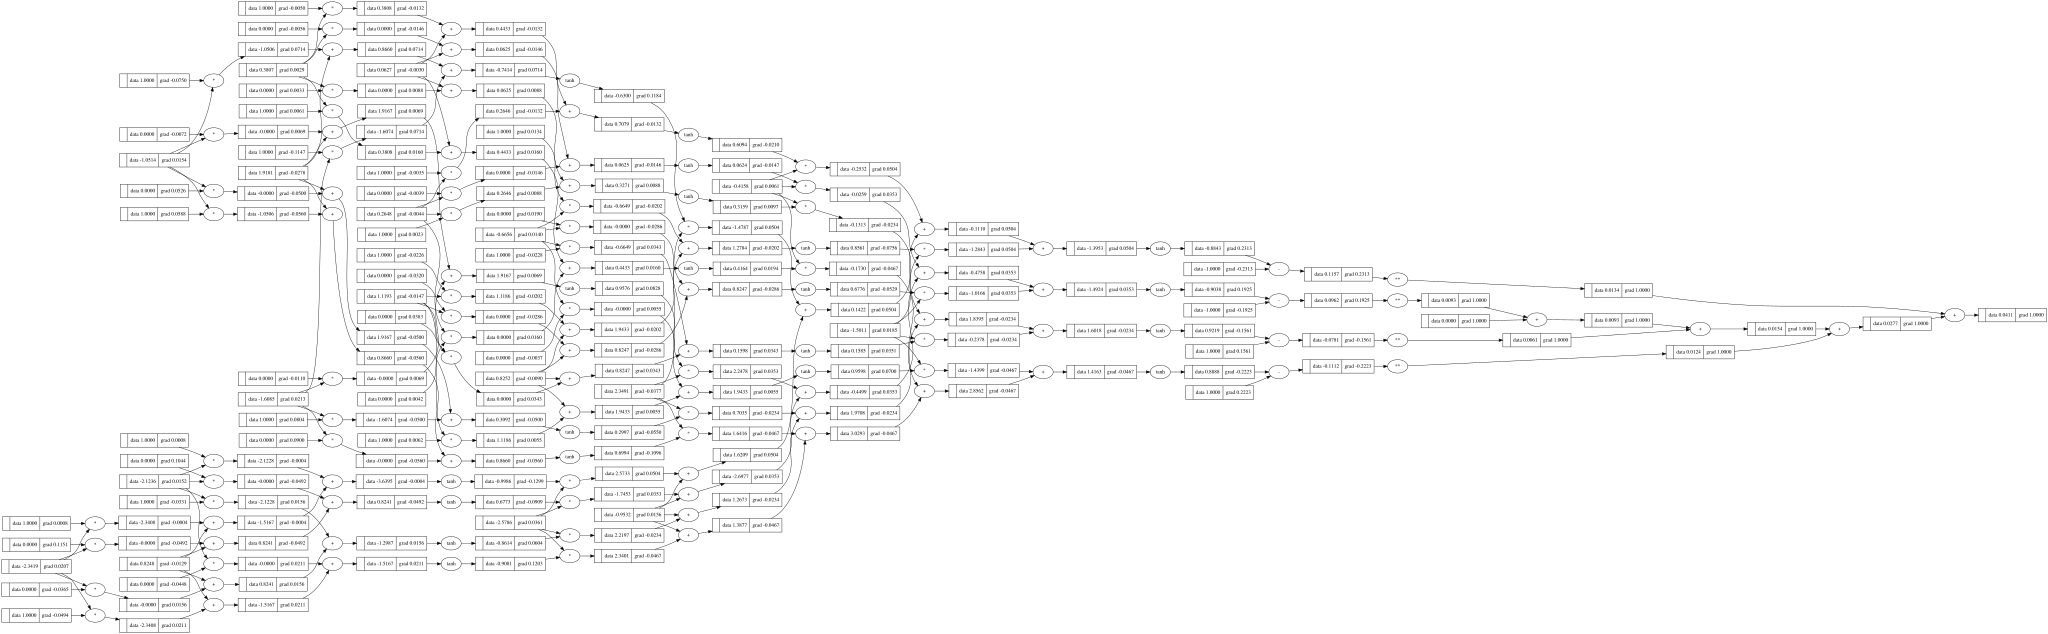

In [299]:
draw_dot(s)

In [300]:
s

Value(data=0.041091173878228124)

In [ ]:
#second experiment(learning rate from -0.05 to -10)

# xs = [[0,0], [0,1], [1,0], [1,1]]
# des = [-1, 1, 1, -1]
# n = MLP([2,4,1])

# for k in range(200):

#  s = 0
#  for i in range(len(xs)):
#   out = n(xs[i])
#   s += (des[i] - out[0]).pow()

#  for a in range(len(n.layers)):
#   for b in range(len(n.layers[a].neurons)):
#    n.layers[a].neurons[b].b.grad = 0
#    for c in range(len(n.layers[a].neurons[b].w)):
#     n.layers[a].neurons[b].w[c].grad = 0

#  s.backward()

#  for a in range(len(n.layers)):
#   for b in range(len(n.layers[a].neurons)):
#    n.layers[a].neurons[b].b.data += -10 * n.layers[a].neurons[b].b.grad
#    for c in range(len(n.layers[a].neurons[b].w)):
#     n.layers[a].neurons[b].w[c].data += -10 * n.layers[a].neurons[b].w[c].grad

#  if k % 20 == 0:
#   print(k, s.data)

# print([n(x)[0].data for x in xs])

In [ ]:
#third experiment(gradients not zeroed)

# xs = [[0,0], [0,1], [1,0], [1,1]]
# des = [-1, 1, 1, -1]
# n = MLP([2,4,1])

# for k in range(200):

#  s = 0
#  for i in range(len(xs)):
#   out = n(xs[i])
#   s += (des[i] - out[0]).pow()

#  s.backward()

#  for a in range(len(n.layers)):
#   for b in range(len(n.layers[a].neurons)):
#    n.layers[a].neurons[b].b.data += -0.05 * n.layers[a].neurons[b].b.grad
#    for c in range(len(n.layers[a].neurons[b].w)):
#     n.layers[a].neurons[b].w[c].data += -0.05 * n.layers[a].neurons[b].w[c].grad

#  if k % 20 == 0:
#   print(k, s.data)

# print([n(x)[0].data for x in xs])

In [ ]:
#fourth experiment(Hidden layer from 4 to 2)

# xs = [[0,0], [0,1], [1,0], [1,1]]
# des = [-1, 1, 1, -1]
# n = MLP([2,2,1])

# for k in range(200):

#  s = 0
#  for i in range(len(xs)):
#   out = n(xs[i])
#   s += (des[i] - out[0]).pow()

#  s.backward()

#  for a in range(len(n.layers)):
#   for b in range(len(n.layers[a].neurons)):
#    n.layers[a].neurons[b].b.data += --0.05 * n.layers[a].neurons[b].b.grad
#    for c in range(len(n.layers[a].neurons[b].w)):
#     n.layers[a].neurons[b].w[c].data += -0.05 * n.layers[a].neurons[b].w[c].grad

#  if k % 20 == 0:
#   print(k, s.data)

# print([n(x)[0].data for x in xs])

In [ ]:
#                                                                                             for those who come after